<a href="https://colab.research.google.com/github/alimor37/WAAM_Weld_ML/blob/main/Phase4_HyperparameterTuning_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coarse Hyperparameter Tuning

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. LOAD DATA FROM GITHUB
# =====================================================================
github_url = "https://raw.githubusercontent.com/alimor37/WAAM_Weld_ML/main/Cleaned_data.xlsx"

print("📥 Loading data from GitHub...")
df = pd.read_excel(github_url)
print("✅ Data loaded successfully!\n")

target_rp = 'Rp0.2_Mpa'
target_rm = 'Rm_Mpa'

# =====================================================================
# 2. DATA CLEANING & STANDARDIZATION
# =====================================================================
df[target_rp] = pd.to_numeric(df[target_rp], errors='coerce')
df[target_rm] = pd.to_numeric(df[target_rm], errors='coerce')

if df['t85_s'].dtype == object:
    df['t85_s'] = df['t85_s'].astype(str).apply(
        lambda x: sum([float(i) for i in x.split('-')])/2 if '-' in x else float(x) if x.replace('.', '', 1).isdigit() else None
    )

trace_elements = ['Nb', 'B', 'O', 'Ti', 'Al', 'S', 'P', 'Mn', 'C', 'Si', 'Cr', 'Ni', 'Mo', 'V', 'Cu', 'N']
for col in trace_elements:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('<', '').str.strip(), errors='coerce')

bead_col = 'No_of_Beads' if 'No_of_Beads' in df.columns else 'No_of_Bead'
if 'SinglePass' not in df.columns:
    df['SinglePass'] = ((df[bead_col] == 1) | (df['Weld_Method'].astype(str).str.strip().isin(['Rapid Arc', 'Laser-Hybrid']) if 'Weld_Method' in df.columns else False)).astype(int)

df['Base1100'] = df['Base_Material'].astype(str).apply(lambda x: 1 if '1100' in str(x) else 0)

# =====================================================================
# 3. FEATURE ENGINEERING (HYBRID SUPER-SET)
# =====================================================================
df['Mn_temp'] = df['Mn'].fillna(df['Mn'].mean())
df['S_temp'] = df['S'].fillna(df['S'].mean())
df['Ti_temp'] = df['Ti'].fillna(df['Ti'].mean())
df['B_temp'] = df['B'].fillna(df['B'].mean())

df['Pcm_t85_Synergy'] = df['Pcm'] * df['t85_s']
df['Mn_S_Ratio'] = df['Mn_temp'] / (df['S_temp'] + 1e-5)
df['Ti_B_Synergy'] = df['Ti_temp'] * df['B_temp']

chemistry_features = ['C', 'Si', 'Mn', 'P', 'S', 'Cr', 'Ni', 'Mo', 'V', 'Nb', 'Cu', 'Al', 'Ti', 'B', 'O', 'N']
process_features = ['Pcm', 't85_s', bead_col, 'Dilution_Ni_pct', 'SinglePass', 'Base1100']
engineered_features = ['Pcm_t85_Synergy', 'Mn_S_Ratio', 'Ti_B_Synergy']

super_features_list = process_features + chemistry_features + engineered_features
super_features = [col for col in super_features_list if col in df.columns]

print(f"Starting Tuning Process on {len(super_features)} Hybrid Features...\n")

loo = LeaveOneOut()

# =====================================================================
# 4. TUNING ENGINE
# =====================================================================
def tune_hybrid_model(target_col, model_name, model, param_grid):
    print(f"{'='*65}")
    print(f" TUNING {model_name} ON HYBRID SET FOR: {target_col}")
    print(f"{'='*65}")

    valid_df = df.dropna(subset=['Pcm', 't85_s', target_col]).copy()
    X = valid_df[super_features].values
    y = valid_df[target_col].values

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', MinMaxScaler()),
        ('regressor', model)
    ])

    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=loo,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X, y)
    best_pipe = grid_search.best_estimator_

    print(f"\n✅ BEST PARAMETERS FOUND:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param.replace('regressor__', '')}: {value}")

    y_pred = cross_val_predict(best_pipe, X, y, cv=loo)
    best_r2 = r2_score(y, y_pred)
    best_rmse = np.sqrt(mean_squared_error(y, y_pred))

    print(f"\n🏆 OPTIMIZED RESULTS:")
    print(f"   - Hybrid LOOCV R²:   {best_r2:.3f}")
    print(f"   - Hybrid LOOCV RMSE: {best_rmse:.1f} MPa")
    print("="*65 + "\n")

# =====================================================================
# 5. RUNNING THE TUNING PROCESS
# =====================================================================
svr_grid = {
    'regressor__kernel': ['rbf', 'linear', 'poly'],
    'regressor__degree': [2, 3],
    'regressor__C': [10, 100, 500, 1000, 2000, 5000],
    'regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'regressor__epsilon': [0.1, 1, 5, 10, 20]
}
tune_hybrid_model(target_rp, 'SVR', SVR(), svr_grid)

en_grid = {
    'regressor__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    'regressor__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1.0],
    'regressor__fit_intercept': [True, False],
    'regressor__tol': [1e-4, 1e-3, 1e-2]
}
tune_hybrid_model(target_rm, 'Elastic Net', ElasticNet(max_iter=20000), en_grid)

📥 Loading data from GitHub...
✅ Data loaded successfully!

Starting Tuning Process on 25 Hybrid Features...

 TUNING SVR ON HYBRID SET FOR: Rp0.2_Mpa
Fitting 28 folds for each of 1080 candidates, totalling 30240 fits

✅ BEST PARAMETERS FOUND:
   - C: 500
   - degree: 2
   - epsilon: 1
   - gamma: scale
   - kernel: rbf

🏆 OPTIMIZED RESULTS:
   - Hybrid LOOCV R²:   0.792
   - Hybrid LOOCV RMSE: 49.0 MPa

 TUNING Elastic Net ON HYBRID SET FOR: Rm_Mpa
Fitting 28 folds for each of 384 candidates, totalling 10752 fits

✅ BEST PARAMETERS FOUND:
   - alpha: 0.001
   - fit_intercept: True
   - l1_ratio: 1.0
   - tol: 0.0001

🏆 OPTIMIZED RESULTS:
   - Hybrid LOOCV R²:   0.729
   - Hybrid LOOCV RMSE: 40.0 MPa



Fine Hyperparameter Tuning

In [21]:
# =====================================================================
# 6. MICRO-TUNING
# =====================================================================


print("🔬 STARTING MICRO-TUNING (COARSE-TO-FINE) ...\n")

svr_micro_grid = {
    'regressor__kernel': ['rbf'],
    'regressor__gamma': ['scale'],
    'regressor__C': [330],
    'regressor__epsilon': [2.3],
    'regressor__degree': [2]
}
tune_hybrid_model(target_rp, 'SVR (Micro-Tuned)', SVR(), svr_micro_grid)


en_micro_grid = {
    'regressor__fit_intercept': [True],
    'regressor__alpha': [0.0000001, 0.000001, 0.000002, 0.000004, 0.000005, 0.000006, 0.000007, 0.000008, 0.000009, 0.00001],
    'regressor__l1_ratio': [1.0],
    'regressor__tol': [0.0004]
}
tune_hybrid_model(target_rm, 'Elastic Net (Micro-Tuned)', ElasticNet(max_iter=50000), en_micro_grid)

🔬 STARTING MICRO-TUNING (COARSE-TO-FINE) ...

 TUNING SVR (Micro-Tuned) ON HYBRID SET FOR: Rp0.2_Mpa
Fitting 28 folds for each of 1 candidates, totalling 28 fits

✅ BEST PARAMETERS FOUND:
   - C: 330
   - degree: 2
   - epsilon: 2.3
   - gamma: scale
   - kernel: rbf

🏆 OPTIMIZED RESULTS:
   - Hybrid LOOCV R²:   0.793
   - Hybrid LOOCV RMSE: 48.9 MPa

 TUNING Elastic Net (Micro-Tuned) ON HYBRID SET FOR: Rm_Mpa
Fitting 28 folds for each of 10 candidates, totalling 280 fits

✅ BEST PARAMETERS FOUND:
   - alpha: 1e-07
   - fit_intercept: True
   - l1_ratio: 1.0
   - tol: 0.0004

🏆 OPTIMIZED RESULTS:
   - Hybrid LOOCV R²:   0.820
   - Hybrid LOOCV RMSE: 32.6 MPa



Final Feature Selection


🔪 RUNNING FINAL RFECV FOR: Rp0.2_Mpa (SVR (Optimized))
✅ Optimal number of features: 17
🥇 The Ultimate 'Golden' Features:
 t85_s, No_of_Beads, SinglePass, Base1100, C, Si, Mn, P, Cr, Ni, Mo, V, Nb, Cu, Ti, B, N



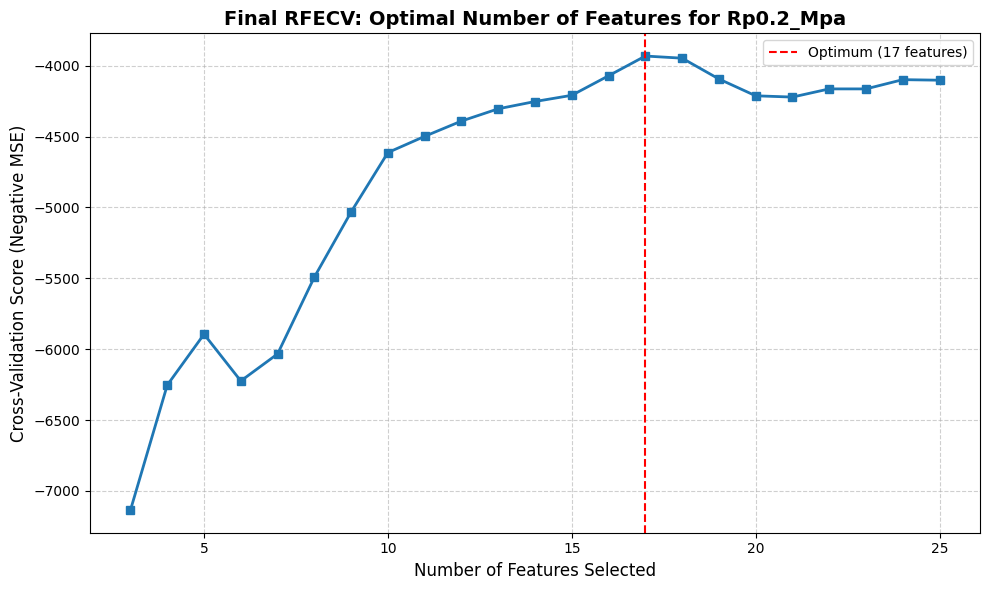


🔪 RUNNING FINAL RFECV FOR: Rm_Mpa (Elastic Net (Optimized))
✅ Optimal number of features: 25
🥇 The Ultimate 'Golden' Features:
 Pcm, t85_s, No_of_Beads, Dilution_Ni_pct, SinglePass, Base1100, C, Si, Mn, P, S, Cr, Ni, Mo, V, Nb, Cu, Al, Ti, B, O, N, Pcm_t85_Synergy, Mn_S_Ratio, Ti_B_Synergy



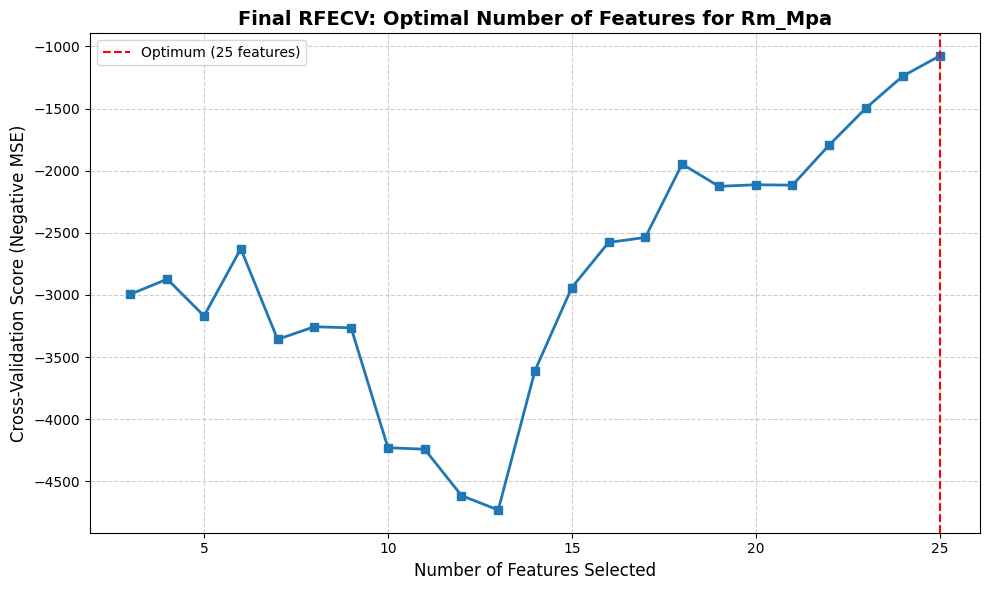

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import warnings

warnings.filterwarnings('ignore')

# 1. Load Data
github_url = "https://raw.githubusercontent.com/alimor37/WAAM_Weld_ML/main/Cleaned_data.xlsx"

df = pd.read_excel(github_url)

target_rp = 'Rp0.2_Mpa'
target_rm = 'Rm_Mpa'

df[target_rp] = pd.to_numeric(df[target_rp], errors='coerce')
df[target_rm] = pd.to_numeric(df[target_rm], errors='coerce')

if df['t85_s'].dtype == object:
    df['t85_s'] = df['t85_s'].astype(str).apply(
        lambda x: sum([float(i) for i in x.split('-')])/2 if '-' in x else float(x) if x.replace('.', '', 1).isdigit() else None
    )

trace_elements = ['Nb', 'B', 'O', 'Ti', 'Al', 'S', 'P', 'Mn', 'C', 'Si', 'Cr', 'Ni', 'Mo', 'V', 'Cu', 'N']
for col in trace_elements:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('<', '').str.strip(), errors='coerce')

bead_col = 'No_of_Beads' if 'No_of_Beads' in df.columns else 'No_of_Bead'
if 'SinglePass' not in df.columns:
    df['SinglePass'] = ((df[bead_col] == 1) | (df['Weld_Method'].astype(str).str.strip().isin(['Rapid Arc', 'Laser-Hybrid']) if 'Weld_Method' in df.columns else False)).astype(int)
df['Base1100'] = df['Base_Material'].astype(str).apply(lambda x: 1 if '1100' in str(x) else 0)

# 2. Hybrid Features
df['Mn_temp'] = df['Mn'].fillna(df['Mn'].mean())
df['S_temp'] = df['S'].fillna(df['S'].mean())
df['Ti_temp'] = df['Ti'].fillna(df['Ti'].mean())
df['B_temp'] = df['B'].fillna(df['B'].mean())

df['Pcm_t85_Synergy'] = df['Pcm'] * df['t85_s']
df['Mn_S_Ratio'] = df['Mn_temp'] / (df['S_temp'] + 1e-5)
df['Ti_B_Synergy'] = df['Ti_temp'] * df['B_temp']

chemistry_features = ['C', 'Si', 'Mn', 'P', 'S', 'Cr', 'Ni', 'Mo', 'V', 'Nb', 'Cu', 'Al', 'Ti', 'B', 'O', 'N']
process_features = ['Pcm', 't85_s', bead_col, 'Dilution_Ni_pct', 'SinglePass', 'Base1100']
engineered_features = ['Pcm_t85_Synergy', 'Mn_S_Ratio', 'Ti_B_Synergy']

super_features = [col for col in (process_features + chemistry_features + engineered_features) if col in df.columns]

loo = LeaveOneOut()

# 3. Final RFECV Function
def run_final_rfecv(target_col, model_name, base_estimator):
    print(f"\n{'='*70}")
    print(f"🔪 RUNNING FINAL RFECV FOR: {target_col} ({model_name})")
    print(f"{'='*70}")

    valid_df = df.dropna(subset=['Pcm', 't85_s', target_col]).copy()
    X = valid_df[super_features].values
    y = valid_df[target_col].values

    imputer = SimpleImputer(strategy='mean')
    scaler = MinMaxScaler()
    X_processed = scaler.fit_transform(imputer.fit_transform(X))

    selector = RFECV(
        estimator=base_estimator,
        step=1,
        cv=loo,
        scoring='neg_mean_squared_error',
        min_features_to_select=3,
        n_jobs=-1
    )

    selector = selector.fit(X_processed, y)
    optimal_num = selector.n_features_
    selected_feats = np.array(super_features)[selector.support_]

    print(f"✅ Optimal number of features: {optimal_num}")
    print(f"🥇 The Ultimate 'Golden' Features:\n {', '.join(selected_feats)}\n")

    plt.figure(figsize=(10, 6))
    plt.title(f'Final RFECV: Optimal Number of Features for {target_col}', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Features Selected', fontsize=12)
    plt.ylabel('Cross-Validation Score (Negative MSE)', fontsize=12)
    plt.plot(range(3, len(selector.cv_results_['mean_test_score']) + 3),
             selector.cv_results_['mean_test_score'], marker='s', color='#1f77b4', linewidth=2)
    plt.axvline(x=optimal_num, color='r', linestyle='--', label=f'Optimum ({optimal_num} features)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================================
# 4. EXECUTE WITH YOUR EXACT OPTIMIZED PARAMETERS
# =====================================================================

# برای SVR خطی (همانطور که قبلا بحث کردیم، باید خطی باشد تا وزن متغیرها قابل خواندن باشد)
svr_final = SVR(kernel='linear', C=330, epsilon=2.3)
run_final_rfecv(target_rp, 'SVR (Optimized)', svr_final)

# برای Elastic Net
# ⚠️ مهم: مقدار alpha را با عددی که در خروجی قبلی‌تان به عنوان "بهترین" چاپ شد، جایگزین کنید (مثلا 0.000005)
best_alpha = 0.000005

en_final = ElasticNet(alpha=best_alpha, l1_ratio=1.0, fit_intercept=True, tol=0.0004, max_iter=50000)
run_final_rfecv(target_rm, 'Elastic Net (Optimized)', en_final)

Results of prediction by SVR and ElasticNet (with their plots)

🎯 FINAL RESULTS FOR: Rp0.2_Mpa | MODEL: SVR (Optimized RBF)
✅ Features Used: 17
🏆 Final LOOCV R²:   0.810
🏆 Final LOOCV RMSE: 46.8 MPa



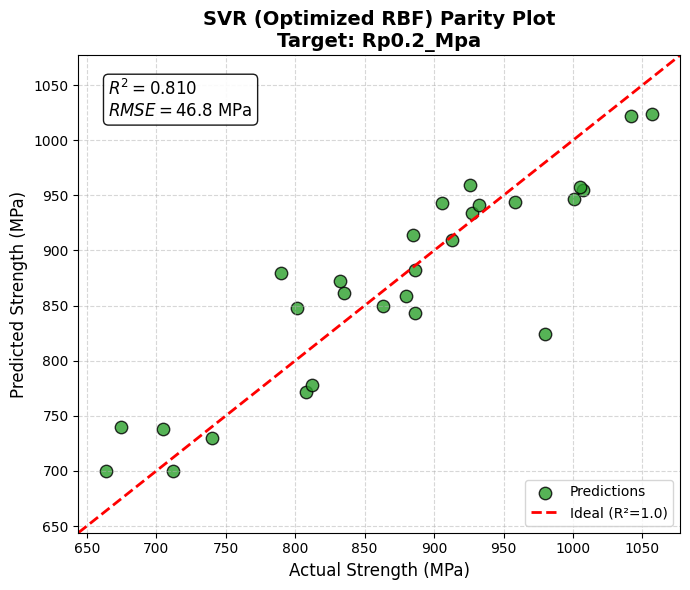

🎯 FINAL RESULTS FOR: Rm_Mpa | MODEL: Elastic Net (Optimized Lasso)
✅ Features Used: 25
🏆 Final LOOCV R²:   0.820
🏆 Final LOOCV RMSE: 32.6 MPa



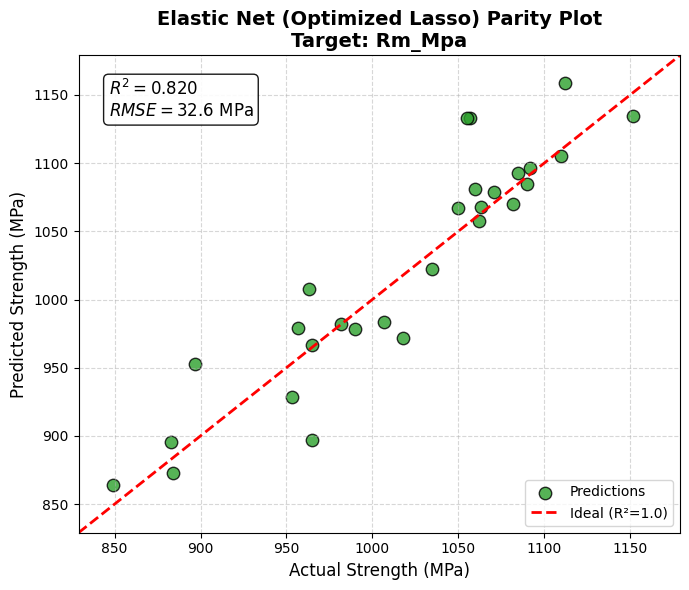

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. LOAD DATA & CLEANING
# =====================================================================
github_url = "https://raw.githubusercontent.com/alimor37/WAAM_Weld_ML/main/Cleaned_data.xlsx"
df = pd.read_excel(github_url)

target_rp = 'Rp0.2_Mpa'
target_rm = 'Rm_Mpa'

df[target_rp] = pd.to_numeric(df[target_rp], errors='coerce')
df[target_rm] = pd.to_numeric(df[target_rm], errors='coerce')

if df['t85_s'].dtype == object:
    df['t85_s'] = df['t85_s'].astype(str).apply(
        lambda x: sum([float(i) for i in x.split('-')])/2 if '-' in x else float(x) if x.replace('.', '', 1).isdigit() else None
    )

trace_elements = ['Nb', 'B', 'O', 'Ti', 'Al', 'S', 'P', 'Mn', 'C', 'Si', 'Cr', 'Ni', 'Mo', 'V', 'Cu', 'N']
for col in trace_elements:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('<', '').str.strip(), errors='coerce')

bead_col = 'No_of_Beads' if 'No_of_Beads' in df.columns else 'No_of_Bead'
if 'SinglePass' not in df.columns:
    df['SinglePass'] = ((df[bead_col] == 1) | (df['Weld_Method'].astype(str).str.strip().isin(['Rapid Arc', 'Laser-Hybrid']) if 'Weld_Method' in df.columns else False)).astype(int)
df['Base1100'] = df['Base_Material'].astype(str).apply(lambda x: 1 if '1100' in str(x) else 0)

# =====================================================================
# 2. HYBRID FEATURES
# =====================================================================
df['Mn_temp'] = df['Mn'].fillna(df['Mn'].mean())
df['S_temp'] = df['S'].fillna(df['S'].mean())
df['Ti_temp'] = df['Ti'].fillna(df['Ti'].mean())
df['B_temp'] = df['B'].fillna(df['B'].mean())

df['Pcm_t85_Synergy'] = df['Pcm'] * df['t85_s']
df['Mn_S_Ratio'] = df['Mn_temp'] / (df['S_temp'] + 1e-5)
df['Ti_B_Synergy'] = df['Ti_temp'] * df['B_temp']

# =====================================================================
# 3. DEFINE FINAL GOLDEN FEATURES
# =====================================================================
# دقیقاً لیست ویژگی‌هایی که RFECV استخراج کرد:
rp_golden_features = [
    't85_s', bead_col, 'SinglePass', 'Base1100', 'C', 'Si', 'Mn', 'P', 'Cr',
    'Ni', 'Mo', 'V', 'Nb', 'Cu', 'Ti', 'B', 'N'
]
rp_features = [col for col in rp_golden_features if col in df.columns]

rm_golden_features = [
    'Pcm', 't85_s', bead_col, 'Dilution_Ni_pct', 'SinglePass', 'Base1100', 'C', 'Si',
    'Mn', 'P', 'S', 'Cr', 'Ni', 'Mo', 'V', 'Nb', 'Cu', 'Al', 'Ti', 'B', 'O', 'N',
    'Pcm_t85_Synergy', 'Mn_S_Ratio', 'Ti_B_Synergy'
]
rm_features = [col for col in rm_golden_features if col in df.columns]

loo = LeaveOneOut()

# =====================================================================
# 4. FINAL EVALUATION FUNCTION
# =====================================================================
def evaluate_and_plot(target_col, model_name, model, final_features):
    valid_df = df.dropna(subset=['Pcm', 't85_s', target_col]).copy()
    X = valid_df[final_features].values
    y = valid_df[target_col].values

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', MinMaxScaler()),
        ('regressor', model)
    ])

    # گرفتن پیش‌بینی‌ها برای همه داده‌ها به روش LOOCV
    y_pred = cross_val_predict(pipe, X, y, cv=loo)

    final_r2 = r2_score(y, y_pred)
    final_rmse = np.sqrt(mean_squared_error(y, y_pred))

    print(f"{'='*60}")
    print(f"🎯 FINAL RESULTS FOR: {target_col} | MODEL: {model_name}")
    print(f"✅ Features Used: {len(final_features)}")
    print(f"🏆 Final LOOCV R²:   {final_r2:.3f}")
    print(f"🏆 Final LOOCV RMSE: {final_rmse:.1f} MPa")
    print(f"{'='*60}\n")

    # رسم نمودار Actual vs Predicted
    plt.figure(figsize=(7, 6))
    plt.scatter(y, y_pred, color='#2ca02c', edgecolor='k', s=80, alpha=0.8, label='Predictions')

    # رسم خط ایده‌آل (y=x)
    min_val = min(min(y), min(y_pred)) - 20
    max_val = max(max(y), max(y_pred)) + 20
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (R²=1.0)')

    plt.title(f'{model_name} Parity Plot\nTarget: {target_col}', fontsize=14, fontweight='bold')
    plt.xlabel('Actual Strength (MPa)', fontsize=12)
    plt.ylabel('Predicted Strength (MPa)', fontsize=12)
    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])

    # اضافه کردن R2 و RMSE روی نمودار
    text_box = f"$R^2 = {final_r2:.3f}$\n$RMSE = {final_rmse:.1f}$ MPa"
    plt.text(0.05, 0.95, text_box, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# =====================================================================
# 5. RUN FINAL MODELS WITH OPTIMIZED HYPERPARAMETERS
# =====================================================================

# مدل SVR با کرنل RBF و پارامترهایی که شما در میکروتیونینگ پیدا کردید
svr_final = SVR(kernel='rbf', C=330, epsilon=2.3, gamma='scale')
evaluate_and_plot(target_rp, 'SVR (Optimized RBF)', svr_final, rp_features)

# مدل Elastic Net با پارامترهای طلایی کشف شده در میکروتیونینگ
best_alpha = 0.000005
en_final = ElasticNet(alpha=best_alpha, l1_ratio=1.0, fit_intercept=True, tol=0.0004, max_iter=50000)
evaluate_and_plot(target_rm, 'Elastic Net (Optimized Lasso)', en_final, rm_features)